In [88]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import numpy as np

1. Carga datos

In [89]:
path=os.getcwd()

df_miopia=pd.read_csv(path+"/dataset_miopia/X_train.csv")
df_miopia_label=pd.read_csv(path+"/dataset_miopia/Y_train.csv")
df_chip=pd.read_csv(path+"/dataset_chipless/chipless_set_train.csv")

2. EDA

In [90]:
df_miopia.head()

,fecha,edad,sexo,origen antepasados (españa),origen antepasados (extranjeros),hº deporte sem,hº naturaleza sem,hº ocio exteriores sem,horas exterior sem,hº estudiar sem,...,OS-DS,CUVAF-Total,CUVAF-Media,CUVAF-DS,Promedio Nasal,DE Nasal,Suma Nasal,Promedio Temporal,DE Temporal,Suma Temporal
0,2/11/20,22,Mujer,Asturias,NaN,0.0,0.0,4.0,4.0,40,...,0.238059,2.256667,0.564167,0.842300,0.905000,1.279863,1.810000,0.223333,0.160278,0.446667
1,2/17/20,23,Mujer,Navarra,NaN,5.0,2.0,2.0,9.0,20,...,2.585654,8.026667,2.006667,1.887316,3.620833,0.503224,7.241667,0.392500,0.102530,0.785000
2,3/10/20,22,Mujer,Bizkaia,NaN,2.0,3.0,8.0,13.0,30,...,0.431335,12.710000,3.177500,0.743668,3.152500,1.248043,6.305000,3.202500,0.314663,6.405000
3,2/26/20,22,Mujer,"Navarra, Extremadura, Cataluña, Aragón",España,0.0,2.0,13.0,15.0,54,...,0.626968,3.551667,0.887917,0.877145,1.003333,1.418928,2.006667,0.772500,0.491439,1.545000
4,2/19/20,23,Mujer,Toledo,NaN,3.0,0.0,0.0,3.0,56,...,1.269257,1.795000,0.448750,0.897500,0.897500,1.269257,1.795000,0.000000,0.000000,0.000000


In [91]:
df_miopia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   fecha                             132 non-null    object 
 1   edad                              132 non-null    int64  
 2   sexo                              132 non-null    object 
 3   origen antepasados (españa)       130 non-null    object 
 4   origen antepasados (extranjeros)  34 non-null     object 
 5   hº deporte sem                    132 non-null    float64
 6   hº naturaleza sem                 132 non-null    float64
 7   hº ocio exteriores sem            130 non-null    float64
 8   horas exterior sem                132 non-null    float64
 9   hº estudiar sem                   132 non-null    int64  
 10  hº ocio inter sem                 132 non-null    int64  
 11  hº act.cerca sem                  0 non-null      float64
 12  horas in

2.1 Comprobamos NULL en columnas y eliminamos aquellas que superen el 5% ya que tenemos pocos datos, hay que ser estrictos

In [92]:
n_nul=df_miopia.isnull().sum()
percentage_null=n_nul/len(df_miopia)*100

print(percentage_null[percentage_null>5])

col_drop=percentage_null[percentage_null>5].index

df_miopia_proc=df_miopia.drop(col_drop,axis=1)

print("Tamaño original: "+str(df_miopia.shape))
print("Tamaño tras eliminar columnas con un % de null superior al 5%: "+str(df_miopia_proc.shape))
print("Columnas eliminadas: ",col_drop)



origen antepasados (extranjeros)     74.242424
hº act.cerca sem                    100.000000
fototipo                             15.909091
Grupo fot                            18.181818
dtype: float64
Tamaño original: (132, 49)
Tamaño tras eliminar columnas con un % de null superior al 5%: (132, 45)
Columnas eliminadas:  Index(['origen antepasados (extranjeros)', 'hº act.cerca sem', 'fototipo',
       'Grupo fot'],
      dtype='object')


In [93]:
num_cols=df_miopia_proc.select_dtypes(include=['number']).columns
num_count=len(num_cols)

cat_cols=df_miopia_proc.select_dtypes(include=['object','category']).columns
cat_count=len(cat_cols)

print("Numero columnas numericas:",num_count,"\nNumero columnas categoricas:",cat_count)

Numero columnas numericas: 32 
Numero columnas categoricas: 13


2.2 Comprobamos el balance entre las 4 labels

In [94]:
len(df_miopia_label) #misma length que en train
print(df_miopia_label.columns)
print(df_miopia_label.isnull().sum().any()) #no hay nulls en label ok,
#M: miopia si o no.
#df_miopia_label.value_counts()
print(df_miopia_label.M.value_counts())
print(df_miopia_label.MM.value_counts())#GRAN DESBALANCE
print(df_miopia_label.Combo.value_counts())
print(df_miopia_label.DCombo.value_counts())

#POSIBLES SOLUCIONES DESBALANCE:
#-Sobremuestreo sintetico de las clases minoritarias==> SMOTE
#-Undersampling==> Eliminar aleatoriamente muestras de la clase mayoritaria para tener una proporcion similar entre minoritaria y mayoritaria ==> 
# #contra perdems muestras por lo que perdemos informacion.

#-Combinar metodos de muestreo (sub o sobremuestreo) con metodos de ensemble robustos
#-Usar métodos de boosting que usen pesos de forma que castiguen mas error de las clases minoritarias en los arboles subsiguientes...
#-No usar accuracy como metrica.

Index(['M', 'MM', 'Combo', 'DCombo'], dtype='object')
False
M
SI    88
NO    44
Name: count, dtype: int64
MM
NO    122
SI     10
Name: count, dtype: int64
Combo
M     70
C     44
MM    18
Name: count, dtype: int64
DCombo
C     44
M1    39
M2    31
MM    18
Name: count, dtype: int64


2.3 Comprobamos correlación entre las variables númericas. 
Importante eliminar aquellas con alta correlacion ya que tenemos pocas observaciones y muchas variables, tiende a overfit y a la multicolinearidad. 

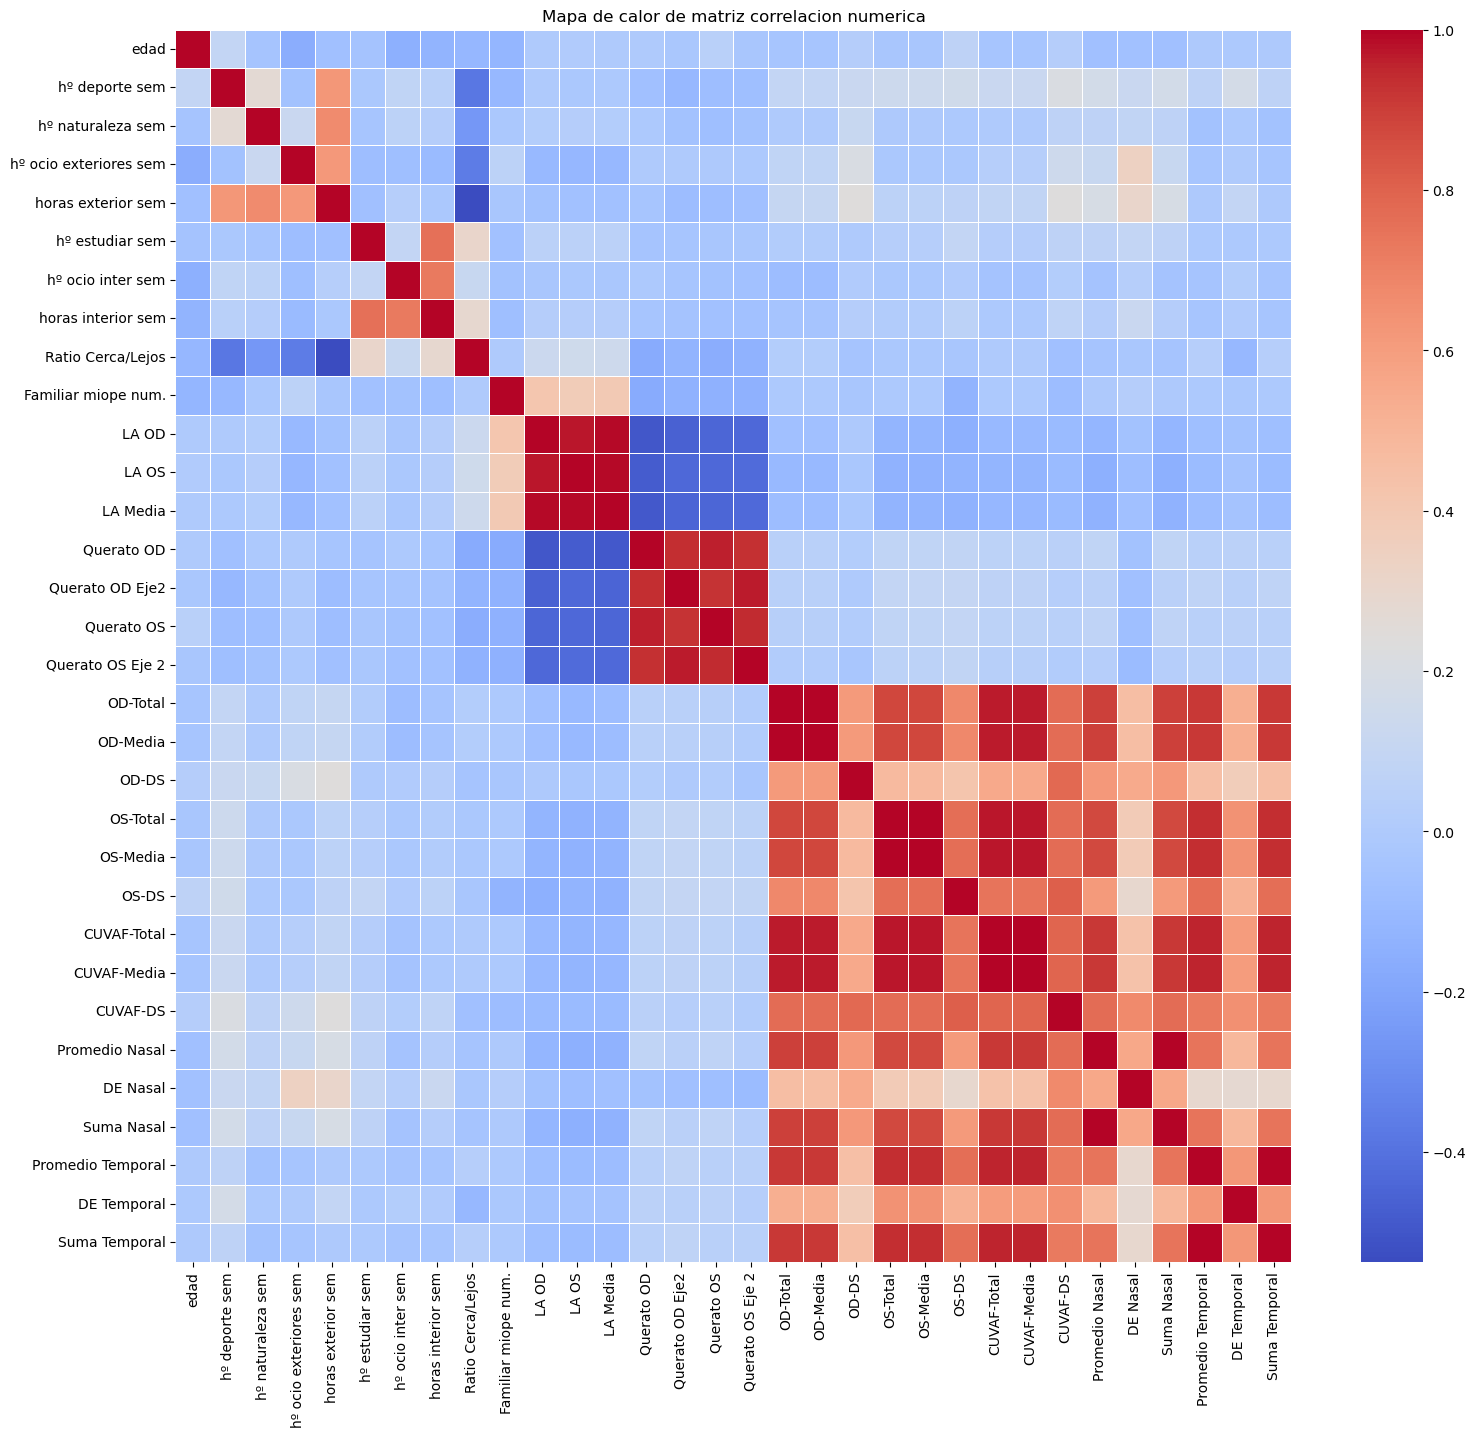

In [95]:
correlacion_num=df_miopia_proc.corr(numeric_only=True)

plt.figure(figsize=(18,16))
sns.heatmap(correlacion_num,annot=False, cmap='coolwarm',fmt=".2f",linewidths=.5,cbar=True)
plt.title("Mapa de calor de matriz correlacion numerica")
plt.show()

#Demasiadas variables correlacionadas... habrá que usar Lasso.

In [96]:
correlacion = df_miopia_proc.corr(numeric_only=True).abs()

upper = correlacion.where(np.triu(np.ones(correlacion.shape), k=1).astype(bool))

# 2. Encontrar pares con correlación > 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("Pares de columnas con alta correlación (> 0.8):")
# Aquí puedes inspeccionar 'upper' para ver los pares exactos
print(to_drop)
print(len(to_drop))

Pares de columnas con alta correlación (> 0.8):
['LA OS', 'LA Media', 'Querato OD Eje2', 'Querato OS', 'Querato OS Eje 2', 'OD-Media', 'OS-Total', 'OS-Media', 'CUVAF-Total', 'CUVAF-Media', 'CUVAF-DS', 'Promedio Nasal', 'Suma Nasal', 'Promedio Temporal', 'Suma Temporal']
15


3. Metodología

Feature selection con lasso y luego aplicamos xgboosting, ideal para clases desbalanceadas así corrige los errores de la clase minoritaria en el siguiente arbol. Utilizar xgboosting con pesos para castigar aún más esos errores de la clase minoritaria.
¿Utilizar smote???

3.1 Modelo prediccion 1 Miopia/No Miopia

In [97]:
#PASOS
#Modelo con lasso. el parametro de penalizacion se obtendra haciendo un CV ESTRATIFICADO., para que encuentre el mejor hiperparametro pero teniendo en cuenta
#que hay clases minotarias x eso estratifico para q mantenga la misma proporcion y en el validation test que en el training set en general.


In [129]:
pipe_num=Pipeline([('imp',SimpleImputer(strategy="median")),('sc',StandardScaler())])
pipe_cat=Pipeline([('imp',SimpleImputer(strategy="most_frequent")),('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'))])
pre=ColumnTransformer([('num',pipe_num,num_cols),('cat',pipe_cat,cat_cols)])

In [130]:
#Lasso como selector variables
selector=SelectFromModel(LogisticRegression(penalty='l1',solver='saga',max_iter=5000))#alfa=2

In [131]:
xgb=XGBClassifier(objective='binary:logistic',eval_metric='aucpr',tree_method='hist',random_state=42)

In [132]:
pipe=Pipeline(steps=[
    ('pre',pre),
    ('sel',selector),
    ('clf',xgb)
])

In [133]:
pipe.get_params().keys()


dict_keys(['memory', 'steps', 'verbose', 'pre', 'sel', 'clf', 'pre__n_jobs', 'pre__remainder', 'pre__sparse_threshold', 'pre__transformer_weights', 'pre__transformers', 'pre__verbose', 'pre__verbose_feature_names_out', 'pre__num', 'pre__cat', 'pre__num__memory', 'pre__num__steps', 'pre__num__verbose', 'pre__num__imp', 'pre__num__sc', 'pre__num__imp__add_indicator', 'pre__num__imp__copy', 'pre__num__imp__fill_value', 'pre__num__imp__keep_empty_features', 'pre__num__imp__missing_values', 'pre__num__imp__strategy', 'pre__num__sc__copy', 'pre__num__sc__with_mean', 'pre__num__sc__with_std', 'pre__cat__memory', 'pre__cat__steps', 'pre__cat__verbose', 'pre__cat__imp', 'pre__cat__ohe', 'pre__cat__imp__add_indicator', 'pre__cat__imp__copy', 'pre__cat__imp__fill_value', 'pre__cat__imp__keep_empty_features', 'pre__cat__imp__missing_values', 'pre__cat__imp__strategy', 'pre__cat__ohe__categories', 'pre__cat__ohe__drop', 'pre__cat__ohe__dtype', 'pre__cat__ohe__feature_name_combiner', 'pre__cat__ohe_

In [135]:
param_grid = {
    # activar/desactivar SMOTE en el grid si lo encapsulas con 'passthrough'
    # ('smote', [ 'passthrough', SMOTENC(categorical_features=cat_idx, random_state=42) ]),
    'sel__estimator__C': [0.2, 0.5, 1.0],
    'clf__max_depth': [2,3,4],
    'clf__learning_rate': [0.03, 0.06, 0.1],
    'clf__n_estimators': [200, 400],
    'clf__subsample': [0.7, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.9, 1.0],
    # si NO usas SMOTE: pesa clases
    'clf__scale_pos_weight': [1.0,  # balanceado
                              # ratio típico:
                              # (n_neg/n_pos) lo puedes calcular por fold en un wrapper si quieres ser purista
                              3.0, 5.0, 8.0]
}

In [136]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

gs = GridSearchCV(pipe, param_grid=param_grid, scoring='average_precision',
                  cv=cv, n_jobs=-1, refit=True, verbose=0)

In [138]:
y_encoded = df_miopia_label['M'].replace({'NO': 0, 'SI': 1})

C:\Users\mbobe\AppData\Local\Temp\ipykernel_19652\2109461817.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_encoded = df_miopia_label['M'].replace({'NO': 0, 'SI': 1})


In [ ]:
#11min
gs.fit(df_miopia_proc, y_encoded) 

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=5, random_state=42),
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imp',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('sc',
                                                                                          StandardScaler())]),
                                                                         Index(['edad', 'hº deporte sem', 'hº naturaleza sem', 'hº ocio exteriores sem',
       'horas exterior sem', 'hº estudiar sem', 'hº ocio inte...
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'clf__colsample_bytree': [0.7, 0.9, 1.0],
                         'clf__learning_rate': [0.03, 0.06, 0.1],
                         'clf__max_depth': [2, 3, 4],
                         'clf__n_estimators': [200, 400],
                         'clf__scale_pos_weight': [1.0, 3.0, 5.0, 8.0],
                         'clf__subsample': [0.7, 0.9, 1.0],
                         'sel__estimator__C': [0.2, 0.5, 1.0]},
             scoring='average_precision')

In [ ]:
print("AUCPR promedio del mejor modelo:",gs.best_score_)#AUCPR
print("Mejores parámetros:",gs.best_params_)
best_model1=gs.best_estimator_ #devuelve el mejor modelo ya entrenado con todo el training set, pero no ha aplicado smote aqui, solo en CV. asi que recomendable
#hacer smote ahora sobre todo si son malos los resultados. no lo son. 

AUCPR promedio del mejor modelo: 0.937412200574334
Mejores parámetros: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 200, 'clf__scale_pos_weight': 1.0, 'clf__subsample': 0.7, 'sel__estimator__C': 0.5}


In [148]:
y_pred=best_model1.predict(df_miopia_proc)
y_pred_proba = best_model1.predict_proba(df_miopia_proc)[:, 1]

In [151]:
print(y_pred)

[1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 0 1
 1 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1
 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0
 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0]


In [155]:
from sklearn.metrics import accuracy_score,roc_auc_score,classification_report
print("Accuracy:",accuracy_score(y_encoded,y_pred))
print("auc-roc:",roc_auc_score(y_encoded,y_pred))
print("clasificacion report (f1 score y recall minoritaria)",classification_report(y_encoded,y_pred))

Accuracy: 0.9696969696969697
auc-roc: 0.9602272727272728
clasificacion report (f1 score y recall minoritaria)               precision    recall  f1-score   support

           0       0.98      0.93      0.95        44
           1       0.97      0.99      0.98        88

    accuracy                           0.97       132
   macro avg       0.97      0.96      0.97       132
weighted avg       0.97      0.97      0.97       132

